# End-to-end resolved lensed-quasar simulation
This notebook connects the package layers into one scientific workflow. It solves a four-image macro lens, derive each image's local convergence/shear and time delay, draw independent stellar populations, generate sparse dynamic IPM maps, evaluate a variable thin disk daily, and sample the resulting resolved light curves with a survey cadence. The CUDA path uses the production-scale $10^7$-ray, $1024^2$ source-map configuration over a full ten years.

In [1]:
import os
from pathlib import Path
import numpy as np
from scipy.ndimage import distance_transform_edt, label as connected_components
import torch
import caustics
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp
plt.rcParams.update(mcp.publication_style())
OUTPUT_DIRECTORY = Path('end_to_end_output')
OUTPUT_DIRECTORY.mkdir(exist_ok=True)
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available and capabilities.triton_importable
runtime_config = mc.RuntimeConfig(
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda,
)
print(mcp.runtime_description())
lens_redshift, source_redshift = 0.0395, 1.695
distances = mc.LensingDistances.from_redshifts(lens_redshift, source_redshift)
macro_lens = caustics.SIE(
    cosmology=caustics.FlatLambdaCDM(), z_l=lens_redshift, z_s=source_redshift,
    x0=0.0, y0=0.0, q=0.72, phi=0.4, Rein=0.9,
)
solutions = mc.solve_caustics_macroimages(
    macro_lens, 0.04, -0.02, initial_grid_size=120, field_of_view_arcsec=2.0
)
for item in solutions:
    print(item.name, f'kappa={item.convergence:.3f}', f'gamma={item.shear:.3f}',
          f'phi_gamma={np.degrees(item.shear_angle_rad):.1f} deg',
          f'delay={item.arrival_time_delay_days:.2f} d')

Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


A kappa=0.392 gamma=0.392 phi_gamma=30.8 deg delay=0.00 d
B kappa=0.424 gamma=0.424 phi_gamma=11.3 deg delay=0.32 d
C kappa=0.600 gamma=0.600 phi_gamma=-56.5 deg delay=0.50 d
D kappa=0.647 gamma=0.647 phi_gamma=-75.1 deg delay=0.74 d


## Independent dynamic stellar fields
The global lens model fixes each macroimage's local convergence, shear magnitude, and shear direction. We assign 20% of the convergence to a smooth sheet and sample the remaining compact convergence from an illustrative truncated Salpeter distribution with slope 2.35, mean mass 0.3 solar masses, and mass ratio 100. Every image receives a different seed and stellar velocity realization over an explicit 30 microarcsecond square. The printed realized compact convergence is allowed to fluctuate around its finite-sample target rather than being silently rescaled.

In [2]:
source_resolution = 1024 if use_cuda else 256
population = mc.StellarPopulation.salpeter(
    mean_mass_solar=0.3,
    mass_ratio=100.0,
    kinematics=mc.IsotropicKinematics(dispersion_km_s=170.0),
)
print('Stellar population:', population.metadata())


Stellar population: {'name': 'salpeter', 'count_override': None, 'mass_function': {'type': 'PowerLawMassFunction', 'minimum_mass': 0.09697081124093573, 'maximum_mass': 9.697081124093573, 'slope': 2.35}, 'kinematics': {'type': 'IsotropicKinematics', 'dispersion_km_s': 170.0, 'bulk_velocity_km_s': (0.0, 0.0), 'lens_redshift': None}}


## A shared variable relativistic thin disk
The source uses a full-Kerr observer transfer with Q2237-like black-hole and disk parameters in g, r, and i. A reproducible broken-power-law driving signal changes its brightness on a daily grid. The driver is shared by all macroimages, but the macro arrival delay shifts only source evolution. Stellar motion and map epochs remain in observer time. This separation is essential for time-delay work.

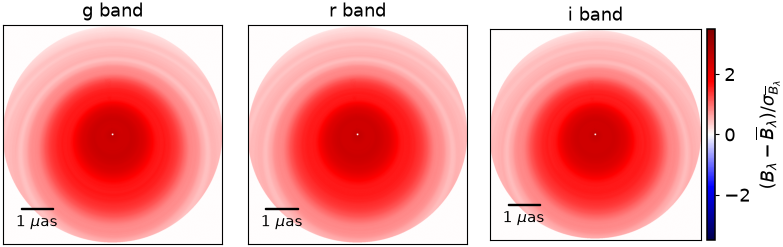

In [3]:
black_hole_mass_solar = 10.0**9.08
spin = 0.74
inclination_deg = 10.0
position_angle_deg = 175.0
trajectory = mc.LinearTrajectory(velocity_uas_per_day=(1.0e-4, 0.5e-4))
driver_times = torch.arange(-100.0, 3651.0)
driver = mc.broken_power_law_driving_signal(
    driver_times, break_timescale_days=200.0, low_frequency_slope=1.0,
    high_frequency_slope=3.0, standard_deviation=0.10, seed=12,
    extrapolation='hold',
)
disk_model = mc.KerrDiskModel(
    black_hole_mass_solar=black_hole_mass_solar,
    eddington_ratio=0.34,
    wavelengths_angstrom=(4770.0, 6231.0, 7625.0),
    band_names=('g', 'r', 'i'),
    spin=spin,
    inclination_deg=inclination_deg,
    position_angle_deg=position_angle_deg,
    source_redshift=source_redshift,
    lamp_fraction=0.1,
    corona_height_above_isco_rg=20.0,
    driving_signal=driver,
    grid=mc.SourceGridConfig(
        shape=source_resolution, enclosed_flux_fraction=0.999, margin=1.05,
    ),
    compile_solver=use_cuda,
    lamppost_nalpha=1024 if use_cuda else 256,
    lamppost_radial_bins=512 if use_cuda else 128,
)
disk_grid = disk_model.recommended_grid(distances)
source = disk_model.pixelate(distances, grid=disk_grid, runtime=runtime_config)
geometry = source.geometry
source_grid = disk_grid.covering_trajectory(
    trajectory, torch.tensor((0.0, 3650.0)), margin=1.05,
)
rg_m = float(mc.gravitational_radius_m(black_hole_mass_solar))
disk_outer_rg = disk_model.support_radius_m(distances) / rg_m
disk_half_size_rg = disk_outer_rg
isco_rg = float(mc.kerr_isco_radius(spin))

# Match the dedicated GR tutorial and manuscript: standardize the real
# broken-power-law source over the complete ten-year sequence, then show
# a representative bright epoch without materializing the full time cube.
display_times = torch.arange(0.0, 3650.0 + 12.5, 25.0, dtype=torch.float64, device=runtime_config.device)
brightness_sum = brightness_square_sum = target_brightness = None
sample_count = 0
brightest_score = -np.inf
for chunk in display_times.split(4):
    values = source.brightness(chunk, dtype=torch.float64, device=runtime_config.device).detach().cpu().numpy().astype(np.float64, copy=False)
    chunk_sum = np.sum(values, axis=0, dtype=np.float64)
    chunk_square_sum = np.sum(values * values, axis=0, dtype=np.float64)
    brightness_sum = chunk_sum if brightness_sum is None else brightness_sum + chunk_sum
    brightness_square_sum = chunk_square_sum if brightness_square_sum is None else brightness_square_sum + chunk_square_sum
    for local_index in range(len(values)):
        score = float(np.sum(values[local_index], dtype=np.float64))
        if score > brightest_score:
            brightest_score = score
            target_brightness = values[local_index].copy()
    sample_count += len(values)
assert target_brightness is not None
mean_brightness = brightness_sum / sample_count
std_brightness = np.sqrt(np.maximum(brightness_square_sum / sample_count - mean_brightness**2, 0.0))
physical_support = (
    source.transfer.hit
    & (source.transfer.radius_rg >= isco_rg)
    & (source.transfer.radius_rg <= disk_outer_rg)
).detach().cpu().numpy()
display_support = np.broadcast_to(physical_support[:, :, None], mean_brightness.shape)
valid_variability = display_support & (std_brightness > np.finfo(np.float64).tiny)
display_brightness = np.divide(
    target_brightness - mean_brightness, std_brightness,
    out=np.zeros_like(target_brightness), where=valid_variability,
)
display_brightness = np.nan_to_num(display_brightness, nan=0.0, posinf=3.5, neginf=-3.5)
for band_index in range(display_brightness.shape[-1]):
    support = display_support[:, :, band_index]
    valid = valid_variability[:, :, band_index]
    repair = support & ~valid
    if np.any(repair) and np.any(valid):
        nearest = distance_transform_edt(~valid, return_distances=False, return_indices=True)
        display_brightness[:, :, band_index][repair] = display_brightness[:, :, band_index][tuple(nearest[:, repair])]
    zero_labels, _ = connected_components(mean_brightness[:, :, band_index] <= 0.0)
    exterior = np.unique(np.concatenate((zero_labels[0], zero_labels[-1], zero_labels[:, 0], zero_labels[:, -1])))
    central = zero_labels[zero_labels.shape[0] // 2, zero_labels.shape[1] // 2]
    isolated = (zero_labels > 0) & ~np.isin(zero_labels, exterior)
    if central > 0:
        isolated &= zero_labels != central
    if np.any(isolated) and np.any(valid):
        nearest = distance_transform_edt(~valid, return_distances=False, return_indices=True)
        display_brightness[:, :, band_index][isolated] = display_brightness[:, :, band_index][tuple(nearest[:, isolated])]
figure, axes = plt.subplots(1, 3, figsize=(8.2, 2.7))
disk_cmap = plt.get_cmap('seismic').copy()
half_uas = 0.5 * disk_grid.field_of_view_uas[0]
for index, (ax, band) in enumerate(zip(axes, geometry.band_names, strict=True)):
    band_brightness = np.asarray(display_brightness[:, :, index], dtype=np.float64)
    artist = ax.imshow(
        band_brightness, origin="lower",
        extent=(-half_uas, half_uas, -half_uas, half_uas),
        cmap=disk_cmap, vmin=-3.5, vmax=3.5,
        aspect="equal",
    )
    ax.set_title(f'{band} band')
    ax.set_xlim(-half_uas, half_uas)
    ax.set_ylim(-half_uas, half_uas)
    mcp.add_scale_bar(ax, 1.0, label=r"1 $\mu$as", color="black")
    mcp.hide_image_axes(ax, keep_frame=True)
mcp.panel_colorbar(figure, axes[-1], artist, label=r"$(B_\lambda-\overline{B}_\lambda)/\sigma_{\overline{B}_\lambda}$")
figure.tight_layout()
disk_figure_path = OUTPUT_DIRECTORY / 'end_to_end_relativistic_disk.png'
figure.savefig(disk_figure_path, dpi=220, bbox_inches='tight', facecolor='white')


## Sparse dynamic maps, daily source evolution
Maps are generated every 25 days, while flux is evaluated every day by interpolating the two map-to-source contractions that bracket each epoch. This avoids constructing a daily map cube. The four panels below retain only the first map for inspection. Each is a point-source magnification field in the corresponding macroimage's local lens coordinates.

A stars= 4587 realized kappa_*= 0.240
B stars= 7745 realized kappa_*= 0.265
C stars= 12097 realized kappa_*= 0.375
D stars= 5325 realized kappa_*= 0.393


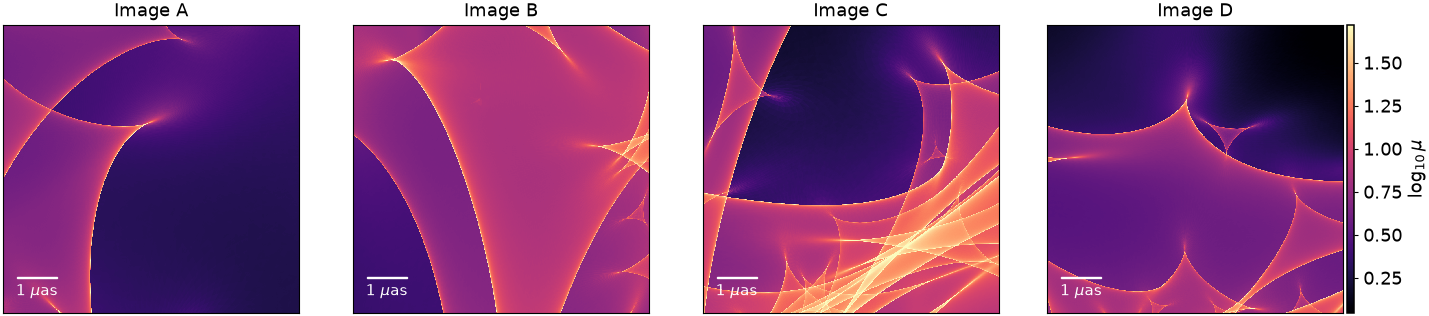

In [4]:
ray_count = 10_000_000 if use_cuda else 262_144
method = mc.production_ipm_config(dynamic=True, rays=ray_count)
schedule = mc.production_dynamic_config()
system = mc.MultiImageMicrolensingSystem.from_macroimage_solutions(
    solutions,
    smooth_matter_fraction=0.20,
    distances=distances,
    source=source,
    source_grid=source_grid,
    stellar_population=population,
    integration_domain="scout",
    duration_days=3650.0,
    light_loss=0.01,
    safety_scale=1.5,
    seed=1001,
    methods=method,
    schedules=schedule,
    trajectories=trajectory,
    runtime=runtime_config,
    caustic_grid_shape=8192,
)
retained_maps = {}

def retain_first(name):
    def observer(index, product):
        if index == 0:
            retained_maps[name] = product
    return observer

map_times = torch.arange(0.0, 3650.0 + 12.5, 25.0)
flux_times = torch.arange(0.0, 3650.0 + 0.5, 1.0)
curves = system.multirate_light_curves(
    map_times_days=map_times.tolist(),
    flux_times_days=flux_times.tolist(),
    map_observers={name: retain_first(name) for name in system.image_names},
)
for name in system.image_names:
    realized = system.image(name).realize()
    print(name, 'stars=', len(realized.stars), 'realized kappa_*=', f'{mc.compact_convergence(realized.stars, realized.stellar_aperture.bounding_region):.3f}')
map_logs = [
    np.log10(np.clip(retained_maps[name].numpy(), 1.0e-12, None))
    for name in system.image_names
]
map_finite = np.concatenate([values[np.isfinite(values)] for values in map_logs])
map_vmin, map_vmax = np.quantile(map_finite, (0.002, 0.998))
figure, axes = plt.subplots(1, 4, figsize=(14.8, 3.4))
for ax, name in zip(axes, system.image_names, strict=True):
    mcp.plot_magnification_map(
        retained_maps[name], ax=ax, colorbar=False, title=f"Image {name}",
        scale_bar_uas=1.0, show_axes=False, vmin=map_vmin, vmax=map_vmax,
    )
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
mcp.panel_colorbar(
    figure, axes[-1], axes[-1].images[0], label=r"$\log_{10}\mu$",
    size="2.5%", pad=0.035,
)
figure.tight_layout()


## Resolved truth and mock survey data
The truth panels use an explicit mock calibration and show i-band brightness in magnitudes. Differences between rows combine the macro delay, distinct microlensing fields, and the parity-dependent local lens. The observation panels then sample each truth curve with alternating g/r/i visits and Rubin-like depth-dependent error bars. The zero points are chosen only to place this normalized tutorial source near 21 mag. Physical source models with calibrated flux units should provide their own zero points.

Using Rubin OpSim WFD cadence: baseline_v4.3.5_10yrs.db


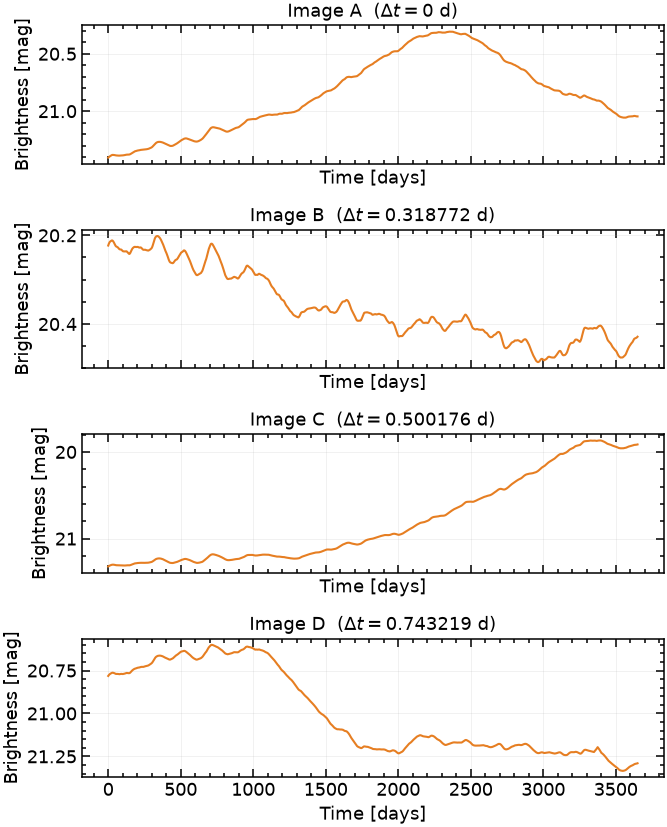

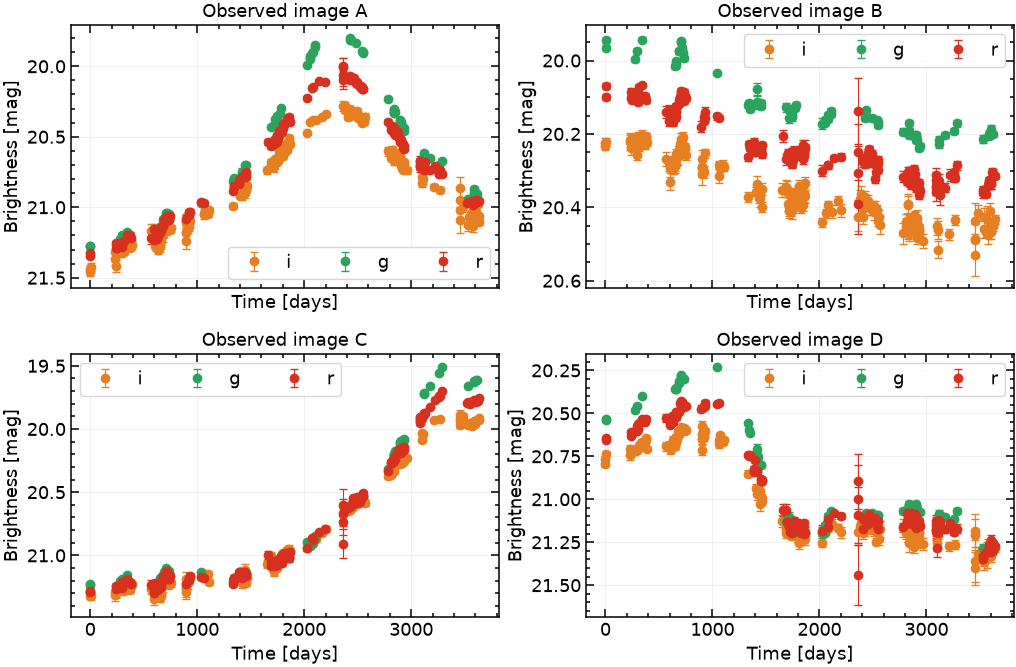

In [5]:
median_flux = curves.flux_tensor().median(dim=1).values.median(dim=0).values
zero_points = {
    band: float(mc.zero_point_flux_for_magnitude(value, 21.0))
    for band, value in zip(geometry.band_names, median_flux, strict=True)
}
mcp.plot_multi_image_light_curves(
    curves,
    band="i",
    magnitude=True,
    normalize=False,
    zero_point_flux=zero_points,
)
opsim_path = mc.find_rubin_opsim_database()
if opsim_path is not None:
    cadence = mc.sample_random_rubin_wfd_cadence(opsim_path, seed=21, duration_days=3650.0)
    cadence = cadence.select_bands(geometry.band_names)
    print("Using Rubin OpSim WFD cadence:", opsim_path.name)
else:
    visit_times = np.arange(2.0, 3650.0, 5.0)
    visit_bands = tuple(("g", "r", "i")[index % 3] for index in range(len(visit_times)))
    cadence = mc.SurveyCadence(visit_times, visit_bands, np.full(len(visit_times), 24.5))
    print("No OpSim database found; using the deterministic fallback cadence.")
observations = mc.observe_multi_image_light_curves(
    curves, cadence, zero_point_flux=zero_points, seed=21
)
figure, axes = plt.subplots(2, 2, figsize=(10.5, 7.0), sharex=True)
for ax, name in zip(axes.flat, system.image_names, strict=True):
    mcp.plot_photometric_observations(
        observations, image=name, ax=ax, marker_size=6.0, capsize=3.0
    )
figure.tight_layout()

## Moving from tutorial to production
Increase the explicit lens field until the desired compact population and guard region are covered. Use the required source-map field and pixel resolution. Raise the IPM ray budget as needed (for example, 10 million rays with k=2, r=2, v=4 is a conservative high-accuracy choice). Tune temporal batches and spatial chunks on the target GPU. And validate map cadence, far-field settings, and label resolution for the chosen source. Use `benchmark_callable` to report first-call and warmed timings separately.